# Nested clustered optimisation with layered constraints and fees

This example shows how to apply constraints at three distinct layers of
`NestedClustered`:

  - the inner optimisation within each cluster,
  - the outer optimisation across synthetic cluster portfolios,
  - and a final overall optimisation pass on the full universe.

It also shows how fees can be attached to the nested stage and to the final overall stage.

> **When to reach for this**
>
> Reach for this when you want cluster structure for robustness, but still need practical
> controls (fees and weight limits) at more than one stage of the nested workflow.

In [1]:
using PortfolioOptimisers, PrettyTables, StableRNGs

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

## 1. Data and shared setup

We use one year of S&P 500 data and compute clusters once. Then we compare three nested setups:

  - inner-only weight bounds,
  - inner + outer bounds plus fees in the nested stage,
  - direct overall asset bounds on `NestedClustered`.

In [2]:
using CSV, TimeSeries, DataFrames, Clarabel

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.95),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel3, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9),
              check_sol = (; allow_local = true, allow_almost = true))]

pr = prior(EmpiricalPrior(), rd)
clr = clusterise(ClustersEstimator(; alg = DBHT()), pr.X)

Clusters
  res ┼ Clustering.Hclust{Float64}([-1 -13; -7 -4; … ; 12 17; 10 18], [0.1, 0.1111111111111111, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 2.0], [5, 20, 17, 3, 9, 6, 2, 1, 13, 7, 4, 19, 14, 10, 16, 18, 11, 8, 12, 15], :DBHT)
    S ┼ 20×20 Matrix{Float64}
    D ┼ 20×20 Matrix{Float64}
    P ┼ nothing
    k ┴ Int64: 4


## 2. Layering constraints in NCO

The nested workflow solves:

  - an inner `MeanRisk` within each cluster, then
  - an outer `MeanRisk` on synthetic cluster returns.

The key wiring rule remains the same: the **outer optimiser must not** consume the
asset-level prior directly; it works on synthetic cluster returns.

In [3]:
jopti_inner = JuMPOptimiser(; pe = pr, slv = slv, wb = WeightBounds(; lb = 0.0, ub = 0.35))
jopto_base = JuMPOptimiser(; slv = slv)
jopto_outer = JuMPOptimiser(; slv = slv, wb = WeightBounds(; lb = 0.0, ub = 0.62))

res_inner = optimise(NestedClustered(; pe = pr, cle = clr,
                                     opti = MeanRisk(; obj = MinimumRisk(),
                                                     opt = jopti_inner),
                                     opto = MeanRisk(; obj = MinimumRisk(),
                                                     opt = jopto_base)), rd)

res_inner_outer = optimise(NestedClustered(; pe = pr, cle = clr, fees = Fees(; l = 0.001),
                                           opti = MeanRisk(; obj = MinimumRisk(),
                                                           opt = jopti_inner),
                                           opto = MeanRisk(; obj = MinimumRisk(),
                                                           opt = jopto_outer)), rd)

wb_overall_assets = WeightBounds(; lb = fill(0.0, length(rd.nx)),
                                 ub = fill(0.20, length(rd.nx)))

WeightBounds
  lb ┼ 20-element Vector{Float64}
  ub ┴ 20-element Vector{Float64}


Use per-asset vectors so the direct `NestedClustered(wb = ...)` bound is applied
to final aggregated asset weights (not just cluster allocations).

In [4]:
res_nested_overall = optimise(NestedClustered(; pe = pr, cle = clr, wb = wb_overall_assets,
                                              fees = Fees(; l = 0.001),
                                              opti = MeanRisk(; obj = MinimumRisk(),
                                                              opt = jopti_inner),
                                              opto = MeanRisk(; obj = MinimumRisk(),
                                                              opt = jopto_outer)), rd)

pretty_table(DataFrame(; :assets => rd.nx, :InnerOnlyWB => res_inner.w,
                       :InnerOuterWBFees => res_inner_outer.w,
                       :NestedDirectOverallWB => res_nested_overall.w);
             formatters = [resfmt])

┌────────┬─────────────┬──────────────────┬───────────────────────┐
│ assets │ InnerOnlyWB │ InnerOuterWBFees │ NestedDirectOverallWB │
│ String │     Float64 │          Float64 │               Float64 │
├────────┼─────────────┼──────────────────┼───────────────────────┤
│   AAPL │       0.0 % │            0.0 % │                 0.0 % │
│    AMD │       0.0 % │            0.0 % │                 0.0 % │
│    BAC │       0.0 % │            0.0 % │                 0.0 % │
│    BBY │       0.0 % │            0.0 % │                 0.0 % │
│    CVX │     3.274 % │          3.304 % │               3.458 % │
│     GE │       0.0 % │            0.0 % │                 0.0 % │
│     HD │       0.0 % │            0.0 % │                 0.0 % │
│    JNJ │    22.366 % │           21.7 % │                20.0 % │
│    JPM │       0.0 % │            0.0 % │                 0.0 % │
│     KO │      9.36 % │          9.996 % │              10.463 % │
│    LLY │       0.0 % │            0.0 % │     

The following audit confirms where the constraints are active.

  - Inner bound (`0.35`) applies to each cluster-level solve.
  - Outer bound (`0.62`) applies to cluster allocation weights.
  - Overall bound (`0.20`) can be applied directly in `NestedClustered`, applied here using per-asset vector bounds.

In [5]:
inner_local_max(res) = maximum(maximum(ri.w) for ri in res.resi)
outer_cluster_max(res) = maximum(res.reso.w)

audit = DataFrame(:Metric => ["Max inner local weight", "Max outer cluster weight",
                              "Max final asset weight"], :Limit => [0.35, 0.62, 0.20],
                  :NestedInnerOnly =>
                      [inner_local_max(res_inner), maximum(res_inner.reso.w),
                       maximum(res_inner.w)],
                  :NestedInnerOuterFees =>
                      [inner_local_max(res_inner_outer), outer_cluster_max(res_inner_outer),
                       maximum(res_inner_outer.w)],
                  :NestedDirectOverallWB => [inner_local_max(res_nested_overall),
                                             outer_cluster_max(res_nested_overall),
                                             maximum(res_nested_overall.w)])

pretty_table(audit; formatters = [resfmt])

┌──────────────────────────┬─────────┬─────────────────┬────────────────────────
│                   Metric │   Limit │ NestedInnerOnly │ NestedInnerOuterFees  ⋯
│                   String │ Float64 │         Float64 │              Float64  ⋯
├──────────────────────────┼─────────┼─────────────────┼────────────────────────
│   Max inner local weight │  35.0 % │          35.0 % │               35.0 %  ⋯
│ Max outer cluster weight │  62.0 % │        63.903 % │               62.0 %  ⋯
│   Max final asset weight │  20.0 % │        22.366 % │               21.7 %  ⋯
└──────────────────────────┴─────────┴─────────────────┴────────────────────────
                                                                1 column omitted


These runs isolate layer placement:

  - inner bounds shape per-cluster compositions,
  - outer bounds shape allocation across clusters,
  - direct `NestedClustered(wb = ...)` bounds constrain the final aggregated asset weights.

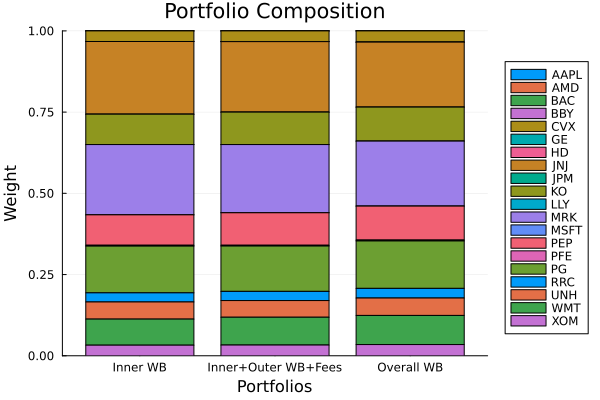

In [6]:
using StatsPlots, GraphRecipes
plot_stacked_bar_composition([res_inner, res_inner_outer, res_nested_overall], rd;
                             xticks = ([1, 2, 3],
                                       ["Inner WB", "Inner+Outer WB+Fees", "Overall WB"]))

## Summary

Layered controls can be applied around `NestedClustered` without giving up the
cluster-based decomposition.

  - Inner `wb` controls weights inside each cluster.
  - Outer `wb` controls allocation across synthetic cluster portfolios.
  - Direct `NestedClustered(wb = ...)` can constrain final asset weights when provided with a weight
    bounds result or estimator.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*